# P4C2 - Augmentez la robustesse de vos modèles

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/blob/master/notebooks/P4C2_robustesse_modele.ipynb)

Dans ce notebook, nous allons rendre les modèles plus robustes gràce à 2 techniques

- la régularisation
- la validation croisée

Nous travaillons sur le dataset des arbres de Paris

Vous trouverez les versions suivantes du datasets

- sur le site [opendata de Paris](https://opendata.paris.fr/explore/dataset/les-arbres/information)
- version [brute](https://github.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/blob/master/data/paris-arbres-2023-09-07.csv) extraite le 10-09-2023, le séparateur est ';'
- version [exploitable](https://github.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/blob/master/data/paris-arbres-clean-2023-09-10.csv): les colonnes ont été renommées, le séparateur est ','
- version [numérisée](https://raw.githubusercontent.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/master/data/paris-arbres-numerical-2023-09-10.csv): les colonnes ont été renommées, le séparateur est ','

Ici nous travaillons sur cette version _numérisée_


# Compensez l'overfit avec la régularisation 

Pour montrer la regularisation avec Ridge il faudrait

- creer un dataset lineaire y = ax + bx^2 ou x est N(0,std) et  std est faible
- le modele qui overfit est ridge sans regularisation avec x, x^2, ... x^N. see from sklearn.preprocessing import PolynomialFeatures 
- puis demo, ajout regularisation permet de compenser l'overfit

voir

- https://www.kaggle.com/code/jonasschroeder/regularization-examples-ridge-lasso-l1-l2
- https://www.analyticsvidhya.com/blog/2016/01/ridge-lasso-regression-python-complete-tutorial/


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures


In [2]:
random_state = 3
X, y = make_regression(n_samples=30, n_features=1, noise=40, random_state=random_state)
input = np.linspace(np.min(X), np.max(X), 100)


## Simple régression linéaire



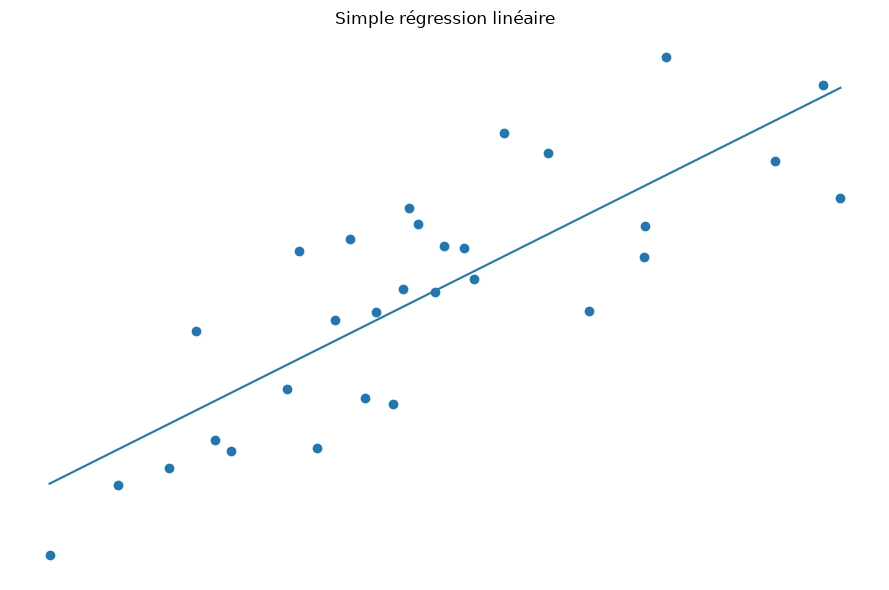

In [3]:
fig = plt.figure( figsize=(9, 6))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(X[:,0], y, label=f"Données source")
model = Ridge(alpha=0)
model.fit(X, y)

y_pred = model.predict(input.reshape(-1, 1))
ax.plot(input, y_pred, label=f"Simple régression linéaire")

ax.set_axis_off()
ax.set_title("Simple régression linéaire")
plt.tight_layout()
plt.show()


## Régression polynomiale de degré 12

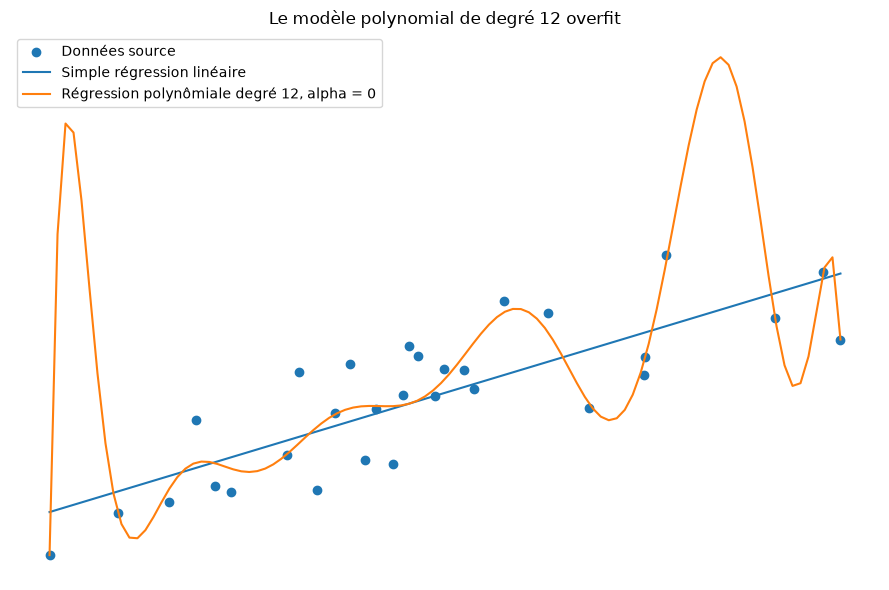

In [ ]:
fig = plt.figure( figsize=(9, 6))
ax = fig.add_subplot(1, 1, 1)
ax.scatter(X[:,0], y, label=f"Données source")
model = Ridge(alpha=0)
model.fit(X, y)

y_pred = model.predict(input.reshape(-1, 1))
ax.plot(input, y_pred, label=f"Simple régression linéaire")

pol = PolynomialFeatures(12, include_bias = False)
XX = pol.fit_transform(X)
px = pol.transform(input.reshape(-1, 1))

# sans regularisation
model = Ridge(alpha=0)
model.fit(XX, y)

y_pred = model.predict(px)
ax.plot(input, y_pred, label=f"Régression polynômiale degré 12, alpha = 0")

ax.set_axis_off()
ax.legend()
ax.set_title("Le modèle polynomial de degré 12 overfit")
plt.tight_layout()
plt.show()


## La régularisation atténue l'overfitting

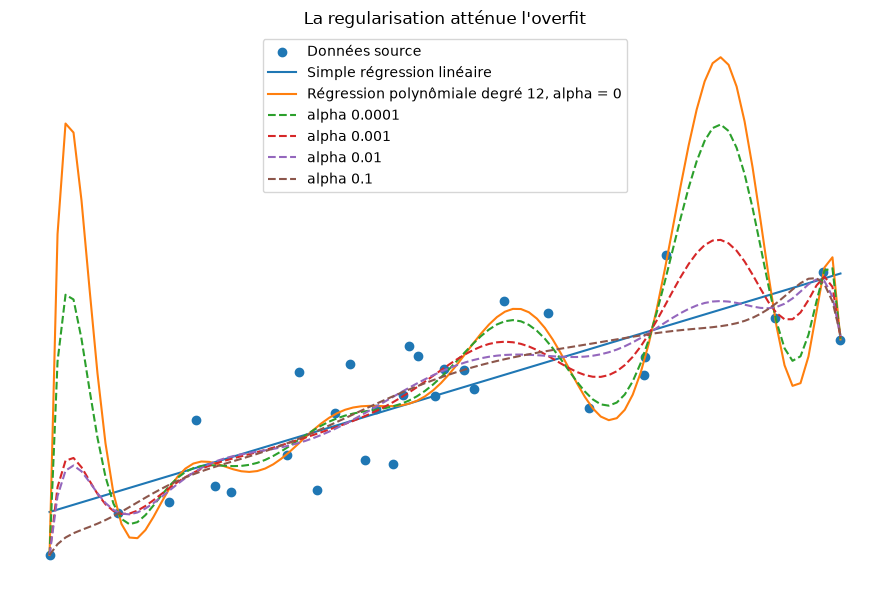

In [5]:
        fig = plt.figure( figsize=(9, 6))
        ax = fig.add_subplot(1, 1, 1)
        ax.scatter(X[:,0], y, label=f"Données source")
        model = Ridge(alpha=0)
        model.fit(X, y)

        y_pred = model.predict(input.reshape(-1, 1))
        ax.plot(input, y_pred, label=f"Simple régression linéaire")

        pol = PolynomialFeatures(12, include_bias = False)
        XX = pol.fit_transform(X)
        px = pol.transform(input.reshape(-1, 1))

        # sans regularisation
        model = Ridge(alpha=0)
        model.fit(XX, y)

        y_pred = model.predict(px)
        ax.plot(input, y_pred, label=f"Régression polynômiale degré 12, alpha = 0")

        for alpha in [0.0001, 0.001, 0.01, 0.1]:

            model = Ridge(alpha=alpha)
            model.fit(XX, y)
            y_pred = model.predict(px)
            ax.plot(input, y_pred, '--' ,label=f"alpha {alpha}")

        ax.set_axis_off()
        ax.legend()
        ax.set_title("La regularisation atténue l'overfit")
        plt.tight_layout()
        plt.show()

# Validation croisée

Retrouvons la valeur optimal de profondeur de l'arbre de classification pour le dataset des arbres de Paris

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier 

Chargeons la version numérisée du dataset des arbres de Paris


In [7]:
filename = 'https://raw.githubusercontent.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/master/data/paris-arbres-numerical-2023-09-10.csv'
data = pd.read_csv(filename)

Précisons la matrice prédiction et la variable cible

In [8]:
X = data[['domanialite', 'arrondissement', 'libelle_francais', 'genre', 'espece', 'circonference_cm', 'hauteur_m']]
y = data.stade_de_developpement.values


Définissons l'espace des valeurs possibles du paramètre :

In [9]:
parameters = {'max_depth':np.arange(2, 30, 2)}

Cette fois, on ne précise pas le paramètre lorsque l'on instancie le modèle :


In [10]:
model = DecisionTreeClassifier(
    random_state = 808
)


Et on entraîne le modele en faisant une validation croisée a 5 plis (fold). 

Notez 

- on précise la fonction de score: roc_auc_ovr qui correspond à ROC_AUC
- on entraîne le modele sur tout le dataset et non pas sur un sous ensemble de train car la validation croisée se charge de gérer la séparation entraînement / test
- comme on a 14 valeurs potentielles du paramètre max_depth et que l'on fait une validation croisée à 5 plis , on doit donc entrainer 4 x 10 = 70 modèles!


In [11]:
clf = GridSearchCV(model, parameters, cv = 5, scoring = 'roc_auc_ovr', verbose = 1)
clf.fit(X, y)

Fitting 5 folds for each of 14 candidates, totalling 70 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...dom_state=808)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 2, 4..., 24, 26, 28])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc_ovr'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a

Les modèle sont entraînés. L'object clf permet de voir directement

- la meilleur valeur des paramètres :





In [12]:
clf.best_params_

{'max_depth': np.int64(10)}

- le meilleur score obtenu :

In [13]:
clf.best_score_

np.float64(0.9364145767567329)

- le meilleur modèle

In [14]:
clf.best_estimator_

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",np.int64(10)
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",808
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number o

In [15]:
# on peut aussi explorer
clf.cv_results_


{'mean_fit_time': array([0.0880609 , 0.13555808, 0.16032977, 0.19682093, 0.23114519,
        0.25845494, 0.27652273, 0.30967631, 0.35811749, 0.43479981,
        0.39512415, 0.34272494, 0.33738475, 0.35248952]),
 'std_fit_time': array([0.01490223, 0.01271761, 0.03594798, 0.01409882, 0.01278212,
        0.01678762, 0.00599567, 0.0142841 , 0.00646539, 0.08065397,
        0.07226631, 0.00972914, 0.00380884, 0.01674114]),
 'mean_score_time': array([0.03566055, 0.03440289, 0.03108411, 0.03068337, 0.03170166,
        0.03612723, 0.0324718 , 0.0345336 , 0.03626347, 0.04475675,
        0.03274603, 0.03366828, 0.0316246 , 0.03312006]),
 'std_score_time': array([0.00572048, 0.00168639, 0.00629396, 0.00128523, 0.00161029,
        0.0043113 , 0.00087757, 0.00323927, 0.00050198, 0.01060328,
        0.00197214, 0.00118371, 0.0002187 , 0.00108661]),
 'param_max_depth': masked_array(data=[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28],
              mask=[False, False, False, False, False, False, 